# Multi-Factor Momentum Trading Strategy

### Part 1: Market Regime Filter
- #### Mechanism: It checks if the market index (e.g., SPY) is trading above its 200-day Simple Moving Average (SMA).
- #### Action: Long positions are only initiated or held if the market is in a bullish regime (price > 200-day SMA). If the market enters a bearish regime, all positions are exited to mitigate systemic risk.

In [372]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
TABLE_INDEX = 0  # first table on the page is the constituent list
TICKER_COL = "Symbol"

headers = {"User-Agent": "Mozilla/5.0"}  # wikipedia blocks default requests UA sometimes
resp = requests.get(WIKI_URL, headers=headers, timeout=15)

tables = pd.read_html(StringIO(resp.text))

df = tables[TABLE_INDEX]

tickers = df[TICKER_COL].astype(str).str.strip().tolist()
tickers = [t.replace(".", "-") for t in tickers]
tickers = sorted(set(tickers))
len(tickers)

503

In [373]:
# Doing a small sample for now
# import random
# random.seed(42)
# random.shuffle(tickers)
# tickers = tickers[:75]

In [374]:
if 'SPY' not in tickers: tickers += ['SPY']

In [375]:
import yfinance as yf
import datetime as dt

N_YEARS = 10
period = dict(
    start = dt.datetime.today() - dt.timedelta(days=365 * N_YEARS)
    , end   = dt.datetime.today()
)

data = yf.download(tickers, **period, auto_adjust=True)

data.tail()

[*********************100%***********************]  504 of 504 completed


Price            Close                                                 \
Ticker               A        AAPL        ABBV        ABNB        ABT   
Date                                                                    
2026-07-09  133.589996  316.220001  249.910004  146.889999  94.400002   
2026-07-10  134.289993  315.320007  248.080002  148.619995  93.930000   
2026-07-13  134.039993  317.309998  248.000000  146.330002  92.110001   
2026-07-14  135.199997  314.859985  244.779999  146.539993  88.959999   
2026-07-15  134.710007  327.500000  244.110001  148.380005  89.269997   

Price                                                                  ...  \
Ticker            ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                   ...   
2026-07-09  101.699997  139.059998  222.649994  393.640015  78.980003  ...   
2026-07-10  101.059998  135.229996  223.639999  395.649994  80.410004  ...   
2026-07-13  103.059998  138.520004  230.610001  386.010010  82.040001  ...   
2026-07-14  101.529999  134.559998  220.779999  392.750000  82.279999  ...   
2026-07-15   98.540001  137.020004  224.559998  390.959991  82.300003  ...   

Price        Volume                                                         \
Ticker           WY     WYNN      XEL       XOM      XYL      XYZ      YUM   
Date                                                                         
2026-07-09  4091600  1344500  5013100  14110200  1337400  3047100  4252900   
2026-07-10  6523600  1327000  3537600   9753500  1399600  3664300  1847100   
2026-07-13  3864900  1287000  4476900  18724300  1507100  3927800  2222600   
2026-07-14  5347600  1274300  4488800  16096400  1465700  4928800  4075600   
2026-07-15  4155370  1007458  6822950   9901276  1483072  9957537  4251256   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2026-07-09  1809800  642500  5611300  
2026-07-10  1543100  593100  5157700  
2026-07-13  2724800  730400  6093600  
2026-07-14  3214200  450700  5321100  
2026-07-15  1857218  620337  5306865  

[5 rows x 2520 columns]

In [376]:
assert not data.empty

In [377]:
assert not data.Close.isna().all(axis=0).sum()

In [378]:
assert not data.Close.isna().all(axis=1).sum()

In [379]:
# Market Regime Filter
LOOKBACK_REGIME = 200
spy_sma_200 = data.Close.SPY.rolling(LOOKBACK_REGIME).mean()
mrf_signal = data.Close.SPY < spy_sma_200

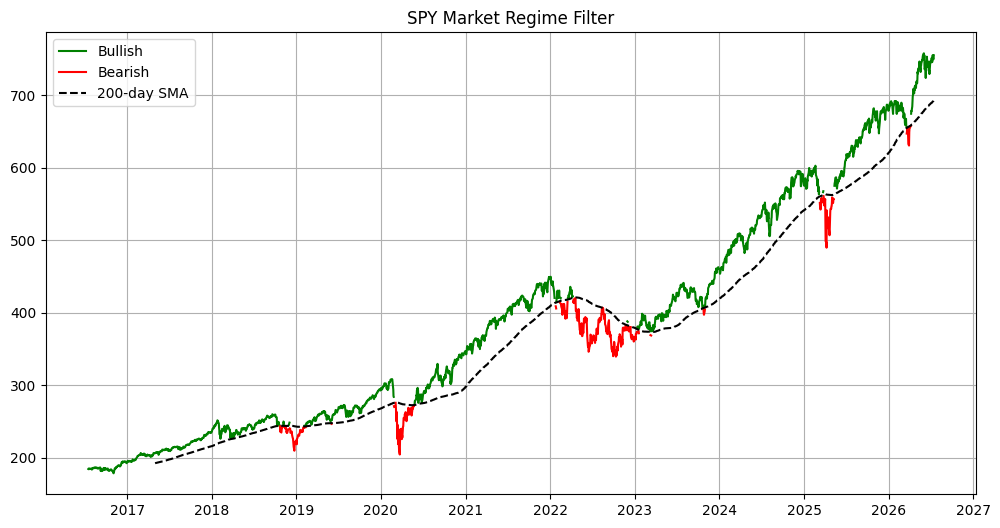

In [380]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot SPY price when filter is ON (green)
plt.plot(
    data.index,
    data.Close.SPY.where(~mrf_signal),
    color="green",
    label="Bullish"
)

# Plot SPY price when filter is OFF (red)
plt.plot(
    data.index,
    data.Close.SPY.where(mrf_signal),
    color="red",
    label="Bearish"
)

# Optional: plot the 200-day SMA
plt.plot(
    data.index,
    spy_sma_200,
    color="black",
    linestyle="--",
    label="200-day SMA"
)

plt.title("SPY Market Regime Filter")
plt.legend()
plt.grid(True)
plt.show()

### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
- #### Mechanism: A stock is only considered a candidate for investment if it is trading above its own 200-day SMA.

In [381]:
LOOK_BACK_TSMOM = 200
def sma_200(x: pd.Series) -> pd.Series:
    return x.rolling(LOOK_BACK_TSMOM).mean()

data_sma_200d = data.Close.apply(sma_200)
data_sma_200d.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-09,130.226749,271.796823,220.501943,130.523075,110.212002,93.90615,214.731326,285.85170,318.913669,67.088160,...,23.801394,111.871109,77.931590,134.851449,129.599151,67.37080,152.772943,91.124578,248.81715,115.203583
2026-07-10,130.271577,272.096635,220.655198,130.638975,110.009222,93.97130,214.231754,285.14950,319.666774,67.197561,...,23.800533,111.744027,77.978212,134.998000,129.494779,67.37025,152.854819,91.077874,248.60270,114.866815
2026-07-13,130.317090,272.414624,220.807954,130.753125,109.800936,94.04430,213.770628,284.49365,320.374453,67.311005,...,23.798888,111.596495,78.023561,135.163262,129.392485,67.38115,152.926557,91.052044,248.36600,114.539275
2026-07-14,130.376141,272.730932,220.957408,130.870425,109.586743,94.09815,213.272164,283.83120,321.106767,67.421836,...,23.798074,111.450709,78.043456,135.328442,129.300058,67.39865,152.980747,91.017447,248.12415,114.209778
2026-07-15,130.445092,273.087706,221.110593,131.003575,109.376955,94.14300,212.817941,283.18320,321.835481,67.534771,...,23.799951,111.311070,78.062074,135.485683,129.207081,67.43930,153.002153,90.988344,247.89015,113.885249


In [382]:
tsmom_filter = data.Close.gt(data_sma_200d)

<Axes: title={'center': 'Number of Stocks Above 200-Day SMA'}, xlabel='Date', ylabel='Number of Valid Stocks'>

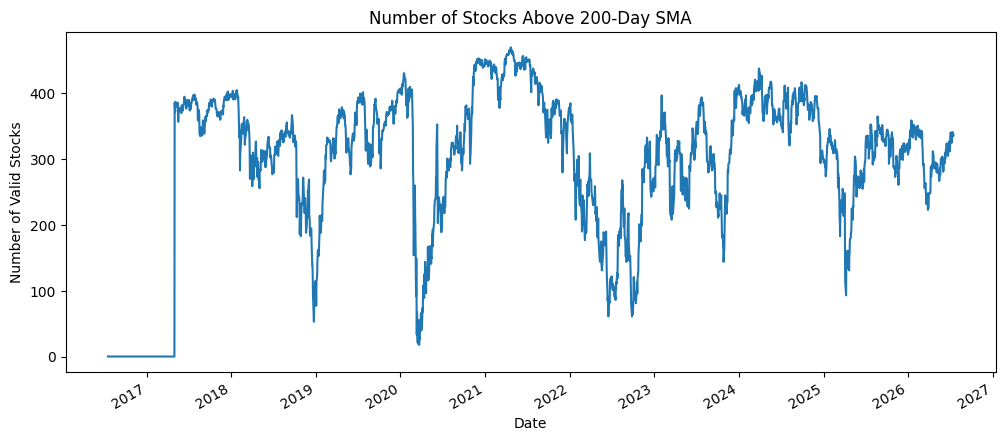

In [383]:
valid_stocks = tsmom_filter.sum(axis=1)

valid_stocks.plot(
    figsize=(12, 5),
    title="Number of Stocks Above 200-Day SMA",
    ylabel="Number of Valid Stocks",
    xlabel="Date"
)

### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
- #### Mechanism: Momentum is calculated over multiple lookback periods (60, 120, and 252 days) and then averaged to produce a robust momentum score.

In [384]:

cross_sect_mom_lookbacks = [60, 120, 252]
LOOKBACK_CSM = max(cross_sect_mom_lookbacks)
SKIP_DAYS = 21  # ~1 month, standard skip in 12-1 momentum

def cross_sect_mom(prices: pd.DataFrame, lookbacks: list[int] = cross_sect_mom_lookbacks, skip: int = SKIP_DAYS) -> pd.DataFrame:
    # price ~1 month ago (skip window), vs price (skip+lookback) ago
    recent = prices.shift(skip)
    raw_signal = pd.concat(
        [(recent / recent.shift(l - skip)) - 1 for l in lookbacks]
    ).groupby(level=0).mean()
    return raw_signal

csm_data = cross_sect_mom(data.Close)
csm_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-09,0.047961,0.256019,0.108315,0.008400,-0.223618,-0.034064,-0.299598,-0.178007,0.396695,0.310945,...,-0.049915,-0.040389,0.055484,0.184484,-0.171647,0.061703,-0.045992,-0.054358,-0.120057,-0.400578
2026-07-10,0.062207,0.210828,0.119716,-0.022765,-0.216349,-0.012565,-0.296559,-0.190490,0.400171,0.307528,...,-0.028342,-0.025001,0.063592,0.174513,-0.172200,0.024609,-0.027317,-0.036617,-0.111440,-0.376365
2026-07-13,0.036703,0.205591,0.109547,-0.043588,-0.234662,-0.008289,-0.308026,-0.209883,0.356845,0.338053,...,-0.043243,-0.046012,0.066977,0.181742,-0.192600,-0.013460,-0.033355,-0.039171,-0.178910,-0.382095
2026-07-14,0.036254,0.243181,0.113446,-0.027463,-0.207777,-0.010442,-0.305308,-0.254205,0.425704,0.284115,...,-0.039045,-0.012516,0.055773,0.140183,-0.163593,0.056633,0.006139,-0.045861,-0.144563,-0.372131
2026-07-15,0.028112,0.219043,0.127659,-0.040229,-0.224216,-0.018557,-0.304476,-0.305354,0.414972,0.310363,...,-0.025525,-0.031794,0.063968,0.152484,-0.151299,0.024688,0.010032,-0.029454,-0.126001,-0.396304


<Axes: title={'center': 'Cross-Sectional Momentums'}, xlabel='Date'>

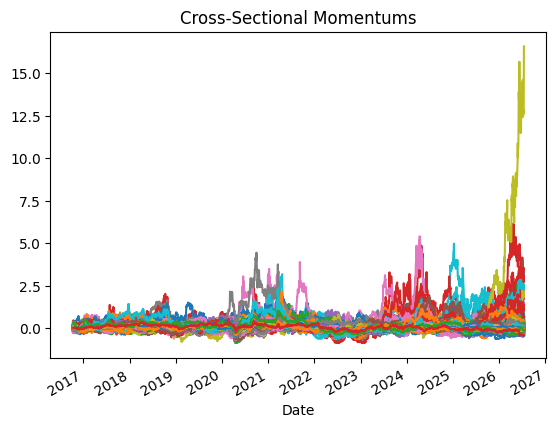

In [385]:
csm_data.plot(
    title='Cross-Sectional Momentums'
    , legend=False
)

### Part 4: Frog-in-the-Pan (FIP) Score: This factor measures the quality and consistency of a stock's trend.
- #### Mechanism: It calculates the ratio of positive daily returns over a 252-day period. A higher score indicates a smoother, more consistent uptrend, rather than one driven by a few large, volatile spikes.


In [386]:
LOOK_BACK_FIP = 252

daily_ret = data.Close.pct_change()

up_days = (daily_ret > 0).rolling(LOOK_BACK_FIP).sum()
down_days = (daily_ret < 0).rolling(LOOK_BACK_FIP).sum()

cum_ret = data.Close.pct_change(LOOK_BACK_FIP)
trend_sign = np.sign(cum_ret)

# Published FIP
fip = trend_sign * (down_days - up_days) / LOOK_BACK_FIP

# Higher = better (invert for ranking)
fip_data = -fip

C:\Users\Danny\AppData\Local\Temp\ipykernel_27348\618010229.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret = data.Close.pct_change()
C:\Users\Danny\AppData\Local\Temp\ipykernel_27348\618010229.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cum_ret = data.Close.pct_change(LOOK_BACK_FIP)


<Axes: title={'center': 'Frog in the Pan Scores'}, xlabel='Date'>

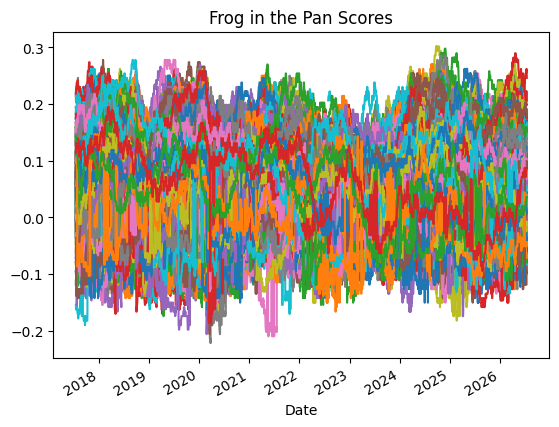

In [387]:
fip_data.plot(
    title='Frog in the Pan Scores'
    , legend=False
)

### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
- #### Mechanism: It calculates the rolling skewness of stock returns over a 90-day window. A high negative skew suggests a stock has a "tail" of large negative returns and is thus penalized in its final score.

In [388]:
LOOKBACK_SKEW = 90
log_returns = np.log(data.Close).diff()
skew_data = log_returns.rolling(LOOKBACK_SKEW).skew()
skew_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-09,2.708186,-0.450673,0.424049,-0.127701,0.061271,-0.370741,-2.045757,-0.174801,-0.402760,0.157876,...,-0.084061,0.266614,0.271367,-0.459116,-0.218579,-0.063863,-0.247724,-1.652495,0.401295,-4.488152
2026-07-10,2.739583,-0.440061,0.453933,-0.165436,0.045184,-0.338267,-2.020511,-0.187038,-0.420594,0.145740,...,0.021845,0.331257,0.258407,-0.458606,-0.240162,-0.047912,-0.226583,-1.630113,0.401652,-4.507969
2026-07-13,2.754051,-0.460634,0.451409,-0.146618,0.062225,-0.357328,-2.014765,-0.195291,-0.423106,0.110430,...,0.036840,0.323060,0.230108,-0.406962,-0.266120,-0.088884,-0.228845,-1.624982,0.424224,-4.551516
2026-07-14,2.764270,-0.454409,0.486138,-0.127026,0.042529,-0.353220,-1.972512,-0.164127,-0.431226,0.089082,...,0.018498,0.358151,0.235269,-0.437378,-0.256671,-0.086652,-0.232662,-1.603214,0.468248,-4.525468
2026-07-15,2.784068,-0.387204,0.477051,-0.141467,0.009188,-0.395001,-1.973130,-0.165182,-0.454929,0.073611,...,-0.004750,0.365581,0.238478,-0.420007,-0.275894,-0.086371,-0.311332,-1.639517,0.474711,-4.591922


<Axes: title={'center': 'Skew'}, xlabel='Date'>

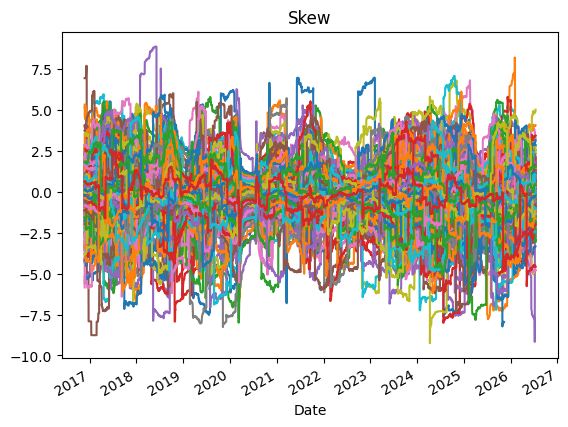

In [389]:
skew_data.plot(
    title='Skew'
    , legend=False
)

### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
- #### Mechanism: Once the top N stocks are selected, portfolio capital is allocated inversely proportional to each stock's historical volatility (standard deviation over 126 days). Less volatile stocks receive a larger capital allocation, and more volatile stocks receive a smaller one with the goal of equalizing the risk contribution of each position.

In [390]:
LOOKBACK_VOLATILITY = 126
vol_data = (
    np.log(data.Close)
    .diff()
    .rolling(LOOKBACK_VOLATILITY)
    .std()
)
vol_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-09,0.022736,0.016739,0.017680,0.021358,0.018141,0.013908,0.033215,0.026826,0.025583,0.017359,...,0.017339,0.021551,0.013332,0.018587,0.017738,0.032734,0.013912,0.019730,0.029123,0.028524
2026-07-10,0.022742,0.016723,0.017316,0.021371,0.018140,0.013876,0.033276,0.026822,0.025583,0.017122,...,0.017463,0.021360,0.013291,0.018494,0.017799,0.032686,0.013911,0.019745,0.028870,0.028453
2026-07-13,0.022711,0.016718,0.016917,0.021395,0.018201,0.013938,0.033244,0.026987,0.025640,0.016777,...,0.017193,0.021424,0.013296,0.018543,0.017769,0.032678,0.013848,0.019876,0.028813,0.028429
2026-07-14,0.022660,0.016739,0.016876,0.021393,0.018428,0.013958,0.033310,0.027207,0.025674,0.016754,...,0.016073,0.021446,0.013265,0.018512,0.017760,0.032694,0.013943,0.020058,0.028853,0.028448
2026-07-15,0.022660,0.017074,0.016879,0.021413,0.018424,0.014094,0.033372,0.027229,0.025576,0.016754,...,0.016079,0.021471,0.013305,0.018510,0.017757,0.032739,0.014290,0.020032,0.028853,0.028448


<Axes: title={'center': 'Volatility'}, xlabel='Date'>

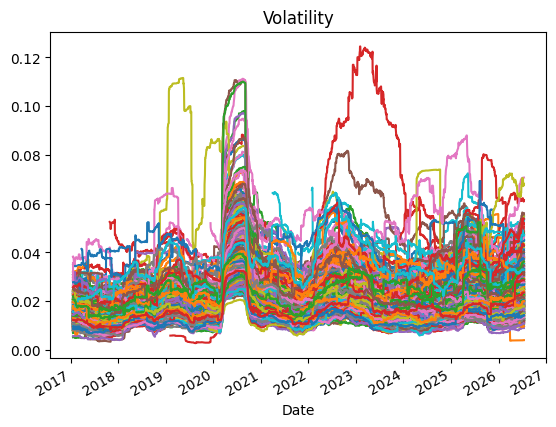

In [391]:
vol_data.plot(
    title='Volatility'
    , legend=False
)

In [392]:
TOP_N      : int  = 10
CSM_FACTOR : int  = 1
FIP_FACTOR : int  = 1
SKEW_FACTOR: int  = 1

TRADE_FREQ : str = 'W-MON'

rebalances = (
    data.Close.index.to_series()
                    .resample(TRADE_FREQ)
                    .first()
                    .dropna()
)

In [393]:
signal_df = pd.DataFrame(
    0.0
    , columns=data.Close.columns
    , index = rebalances
)

latest_date = signal_df.index[-1]

def normalize(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

def build_signal(d: pd.Timestamp):
    ### Part 1: Market Regime Filter
    if mrf_signal.loc[d]: return # all rows are already 0

    ### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
    # TODO  Add a hysteresis band (e.g., require close > SMA × 1.02 to re-enter, < SMA × 0.98 to exit).
    ### Add a hysteresis band (e.g., require close > SMA × 1.02 to re-enter, < SMA × 0.98 to exit).
    ### Use a slope condition too (SMA rising) not just price vs SMA level.
    ### Blend a faster and slower regime signal (e.g. 50/200 SMA agreement) to reduce false regime flips.
    basket = signal_df.columns[
        tsmom_filter.loc[d]
    ]

    csm = (
        normalize(csm_data.loc[d][basket][lambda x: x > 0])
        if not basket.empty else pd.Series(dtype=float)
    )

    if basket.empty or csm.empty:
        signal_df.loc[d] = signal_df.shift(1).loc[d]
        return

    # TODO only trade if weight change exceeds a threshold, or de-rank churny names
    winners = csm.index

    ### Part 4: Frog-in-the-Pan (FIP) Score:
    fip  = normalize(fip_data.loc[d, winners])

    ### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
    skew = normalize(skew_data.loc[d, winners])

    score = (
          (CSM_FACTOR  * csm)
        + (FIP_FACTOR  * fip)
        + (SKEW_FACTOR * skew)
    )
    top_picks = score.sort_values(ascending=False).head(TOP_N)

    ### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
    vol = vol_data.loc[d, top_picks.index]
    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()

    signal_df.loc[d, weights.index] = weights

build_signal(latest_date)

signal_df.loc[latest_date].sort_values().tail(TOP_N)

Ticker
SNDK    0.053357
LITE    0.059124
MU      0.065058
WDC     0.070272
DELL    0.072692
FLEX    0.074189
DVA     0.115866
URI     0.116815
DOC     0.170732
MNST    0.201896
Name: 2026-07-14 00:00:00, dtype: float64

In [394]:
for d in signal_df.index: build_signal(d)

In [395]:
df_r = data.Close.apply(
    lambda x: np.log(x).diff().shift(-1)
    , axis=0
)

In [396]:
weights = signal_df.reindex(df_r.index).ffill().fillna(0)
df_r_signal = (df_r * weights).ffill()

In [397]:
r = df_r_signal.sum(axis=1)
mask = (r.index.year>=2016) & (r.index.year<=2026)
r = r[mask]

In [398]:
equity = np.exp(r.cumsum())

<Axes: title={'center': 'Equity Over Time'}, xlabel='Date'>

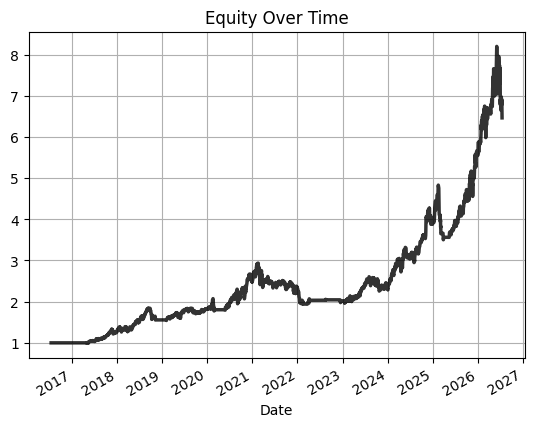

In [399]:
equity.plot(
    title = 'Equity Over Time'
    , color='black'
    , grid=True
    , linewidth=2.5
    , alpha=0.8
)

Bench Mark Notes
- [CAGR](https://www.investopedia.com/terms/c/cagr.asp)
- [sorintino](https://www.investopedia.com/terms/s/sortinoratio.asp#:~:text=Example%20of%20How%20to%20Use%20the%20Sortino%20Ratio)

In [400]:
n_years = (equity.index[-1] - equity.index[0]).days / 365.25
n_years


9.990417522245037

In [401]:
cagr = (((equity.iloc[-1]/equity.iloc[0]) ** (1/n_years)) - 1) * 100
cagr

np.float64(20.5382834000573)

In [402]:
freq: int = 252
rf  : int = 0

In [403]:
ann_vol = r.std() * np.sqrt(freq)
sharpe = (r.mean() * freq - rf) / ann_vol
sharpe

np.float64(0.8558922017342903)

In [404]:
downside = r[r < 0]
sortino = (r.mean() * freq - rf) / (downside.std() * np.sqrt(freq))
sortino

np.float64(0.9545598372299258)